# 00 · Perfilamiento de la fuente — ORCA v1.0 (Entrega 1)

**Objetivo:** evidenciar, con consultas reproducibles a la API de datos.gov.co, por qué se seleccionó
**SECOP II – Contratos Electrónicos** (`jbjy-vk9h`) como fuente principal, y dimensionar el problema de negocio.

* No descarga el dataset completo (≈ 6 millones de filas): usa agregaciones SoQL del lado del servidor.
* El pipeline de ingesta completo es alcance de la **Entrega 2** (`01_ingesta.ipynb`).
* Alcance del caso: entidades con sede en **Antioquia**, contratos firmados desde el 1-ene-2024.

In [1]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE = "https://www.datos.gov.co"
CONTRATOS = "jbjy-vk9h"   # SECOP II - Contratos Electrónicos
PROCESOS = "p6dx-8zbt"    # SECOP II - Procesos de Contratación
FILTRO = "departamento='Antioquia' AND fecha_de_firma >= '2024-01-01'"
pd.set_option("display.max_colwidth", 80)


def soql(dataset: str, reintentos: int = 3, **params) -> pd.DataFrame:
    """Consulta SoQL con reintentos (la API pública puede responder lento)."""
    p = {f"${k}": v for k, v in params.items()}
    for intento in range(1, reintentos + 1):
        try:
            r = requests.get(f"{BASE}/resource/{dataset}.json", params=p, timeout=180)
            r.raise_for_status()
            r.encoding = "utf-8"
            return pd.DataFrame(r.json())
        except requests.RequestException:
            if intento == reintentos:
                raise
            time.sleep(10 * intento)

## 1. Metadatos de la fuente (API de metadatos de Socrata)

In [2]:
filas = []
for ds in [CONTRATOS, PROCESOS]:
    m = requests.get(f"{BASE}/api/views/{ds}.json", timeout=60).json()
    cf = m.get("metadata", {}).get("custom_fields", {})
    filas.append({
        "id": ds, "nombre": m["name"], "publicador": m.get("attribution"),
        "licencia": (m.get("license") or {}).get("name"),
        "columnas": len(m["columns"]),
        "frecuencia": cf.get("Información de Datos", {}).get("Frecuencia de Actualización"),
        "ultima_actualizacion": pd.to_datetime(m["rowsUpdatedAt"], unit="s").date(),
    })
meta = pd.DataFrame(filas)
meta

,id,nombre,publicador,licencia,columnas,frecuencia,ultima_actualizacion
0,jbjy-vk9h,SECOP II - Contratos Electrónicos,"Agencia Nacional de Contratación Pública - Colombia Compra Eficiente, Bogotá...",Creative Commons Attribution | Share Alike 4.0 International,95,Diaria,2026-09-27
1,p6dx-8zbt,SECOP II - Procesos de Contratación,"Agencia Nacional de Contratación Pública - Colombia Compra Eficiente, Bogotá...",Creative Commons Attribution | Share Alike 4.0 International,59,Diaria,2026-09-26


## 2. Dimensión del problema en Antioquia

In [3]:
tot = soql(CONTRATOS, select="count(*) as contratos, sum(valor_del_contrato) as valor, "
           "count(distinct nombre_entidad) as entidades, count(distinct documento_proveedor) as proveedores",
           where=FILTRO)
tot = tot.astype(float)
tot["valor_billones_cop"] = tot["valor"] / 1e12
tot[["contratos", "valor_billones_cop", "entidades", "proveedores"]].round(1)

,contratos,valor_billones_cop,entidades,proveedores
0,302507.0,56.4,565.0,83932.0


In [4]:
mod = soql(CONTRATOS, select="modalidad_de_contratacion, count(*) as n", where=FILTRO,
           group="modalidad_de_contratacion", order="n DESC")
mod["n"] = mod["n"].astype(int)
mod["pct"] = (100 * mod["n"] / mod["n"].sum()).round(1)
directa = mod[mod.modalidad_de_contratacion.str.contains("directa", case=False)]["pct"].sum()
print(f"Contratación directa (con y sin ofertas): {directa:.1f} % de los contratos")
mod.head(8)

Contratación directa (con y sin ofertas): 85.5 % de los contratos


,modalidad_de_contratacion,n,pct
0,Contratación directa,252642,83.5
1,Contratación régimen especial,20412,6.7
2,Mínima cuantía,15371,5.1
3,Contratación Directa (con ofertas),5917,2.0
4,Contratación régimen especial (con ofertas),2741,0.9
5,Selección abreviada subasta inversa,2549,0.8
6,Selección Abreviada de Menor Cuantía,1766,0.6
7,Licitación pública,478,0.2


## 3. Efecto de la Ley de Garantías (Ley 996 de 2005)
Las elecciones de 2026 restringen la contratación directa en los cuatro meses previos a la elección presidencial.
Si el patrón de firma se concentra justo antes de la restricción, hay una **bandera roja** de planeación.

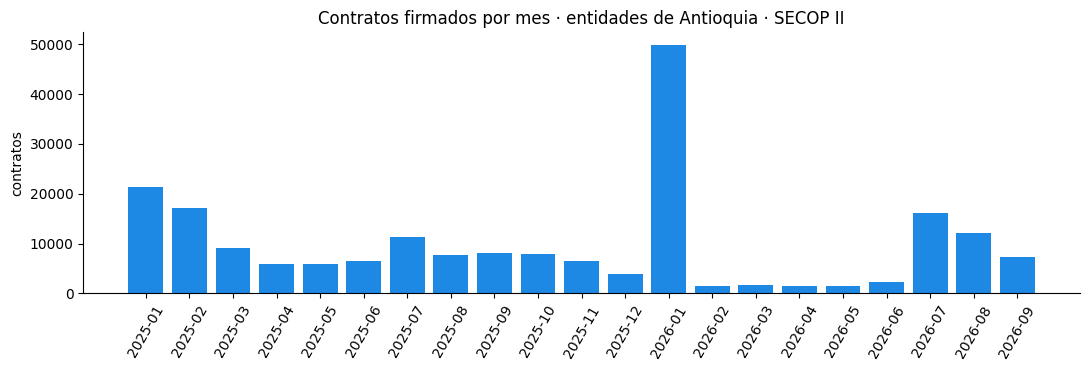

,mes,n,directa,pct_directa
0,2025-01,21419,20219,94.4
1,2025-02,17060,15456,90.6
2,2025-03,9152,7540,82.4
3,2025-04,5872,4255,72.5
4,2025-05,5810,4079,70.2
5,2025-06,6591,5104,77.4
6,2025-07,11275,9460,83.9
7,2025-08,7654,6252,81.7
8,2025-09,8060,6496,80.6
9,2025-10,7821,5758,73.6


In [5]:
mes = soql(CONTRATOS,
           select="date_trunc_ym(fecha_de_firma) as mes, count(*) as n, "
                  "sum(case(modalidad_de_contratacion like '%directa%', 1, true, 0)) as directa",
           where="departamento='Antioquia' AND fecha_de_firma >= '2025-01-01' AND fecha_de_firma < '2026-10-01'",
           group="mes", order="mes")
mes["mes"] = pd.to_datetime(mes["mes"]).dt.strftime("%Y-%m")
mes[["n", "directa"]] = mes[["n", "directa"]].astype(int)
mes["pct_directa"] = (100 * mes["directa"] / mes["n"]).round(1)

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(mes["mes"], mes["n"], color="#1e88e5")
ax.set_title("Contratos firmados por mes · entidades de Antioquia · SECOP II")
ax.set_ylabel("contratos")
ax.tick_params(axis="x", rotation=60)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
mes

## 4. Datos personales (PII) presentes en la fuente → insumo para la clasificación

In [6]:
doc = soql(CONTRATOS, select="tipodocproveedor, count(*) as n", where=FILTRO,
           group="tipodocproveedor", order="n DESC")
doc["n"] = doc["n"].astype(int)
doc["pct"] = (100 * doc["n"] / doc["n"].sum()).round(1)
doc

,tipodocproveedor,n,pct
0,Cédula de Ciudadanía,246445,81.5
1,NIT,54753,18.1
2,Otro,409,0.1
3,No Definido,376,0.1
4,Cédula de Extranjería,365,0.1
5,Permiso por Protección Temporal,131,0.0
6,Pasaporte,15,0.0
7,Tarjeta de Identidad,7,0.0
8,Permiso especial de permanencia,3,0.0
9,Registro Civil,3,0.0


In [7]:
muestra = soql(CONTRATOS, where="departamento='Antioquia' AND fecha_de_firma >= '2025-01-01'",
               order="fecha_de_firma DESC", limit=5000)
pii_cols = ["documento_proveedor", "proveedor_adjudicado", "nombre_representante_legal",
            "identificaci_n_representante_legal", "nombre_supervisor", "n_mero_de_documento_supervisor",
            "nombre_ordenador_del_gasto", "n_mero_de_documento_ordenador_del_gasto", "n_mero_de_cuenta"]
PLACEHOLDERS = {"no definido", "sin descripcion", "no aplica", "n/a", ""}
res = []
for c in pii_cols:
    s = muestra[c].astype(str).str.strip().str.lower()
    res.append({"campo": c, "con_valor_real_%": round(100 * (~s.isin(PLACEHOLDERS)).mean(), 1)})
pd.DataFrame(res)

,campo,con_valor_real_%
0,documento_proveedor,99.6
1,proveedor_adjudicado,100.0
2,nombre_representante_legal,99.9
3,identificaci_n_representante_legal,18.0
4,nombre_supervisor,76.7
5,n_mero_de_documento_supervisor,76.7
6,nombre_ordenador_del_gasto,79.7
7,n_mero_de_documento_ordenador_del_gasto,79.7
8,n_mero_de_cuenta,0.0


## 5. Hallazgos iniciales de calidad (se formalizan como reglas en la Entrega 2)

In [8]:
def contar(where):
    return int(soql(CONTRATOS, select="count(*) as n", where=where)["n"][0])

base_a = "departamento='Antioquia'"
calidad = pd.DataFrame([
    {"dimension": "Completitud", "regla": "fecha_de_firma nula (todas las fechas)",
     "registros": contar(base_a + " AND fecha_de_firma IS NULL")},
    {"dimension": "Validez", "regla": "ciudad = 'No Definido'",
     "registros": contar(FILTRO + " AND ciudad = 'No Definido'")},
    {"dimension": "Exactitud", "regla": "valor_del_contrato = 0",
     "registros": contar(FILTRO + " AND valor_del_contrato = 0")},
    {"dimension": "Exactitud", "regla": "valor_del_contrato > 100.000 millones",
     "registros": contar(FILTRO + " AND valor_del_contrato > 100000000000")},
    {"dimension": "Consistencia", "regla": "fecha fin < fecha inicio",
     "registros": contar(FILTRO + " AND fecha_de_fin_del_contrato < fecha_de_inicio_del_contrato")},
])
calidad

,dimension,regla,registros
0,Completitud,fecha_de_firma nula (todas las fechas),40638
1,Validez,ciudad = 'No Definido',20706
2,Exactitud,valor_del_contrato = 0,2848
3,Exactitud,valor_del_contrato > 100.000 millones,47
4,Consistencia,fecha fin < fecha inicio,187


In [9]:
print("Duplicados de id_contrato en la muestra:", muestra["id_contrato"].duplicated().sum())
print("Nulos disfrazados en nombre_del_banco:", (muestra["nombre_del_banco"].str.lower() == "no definido").mean().round(3))
nulos = (muestra.isna().mean() * 100).round(1).sort_values(ascending=False)
nulos[nulos > 0].head(10).to_frame("% nulos (muestra 5.000)")

Duplicados de id_contrato en la muestra: 0
Nulos disfrazados en nombre_del_banco: 1.0


,% nulos (muestra 5.000)
fecha_inicio_reversi_n,100.0
fecha_fin_reversi_n,100.0
ultima_actualizacion,97.8
fecha_de_notificaci_n_de_prorrogaci_n,95.6
fecha_fin_liquidacion,82.9
fecha_inicio_liquidacion,82.9
fecha_de_inicio_del_contrato,21.0


## 6. Cruce con el dataset de Procesos (medir competencia)
`contratos.proceso_de_compra` = `procesos.id_del_portafolio`. Esto permite la bandera roja
*“proceso competitivo con un único oferente”*.

In [10]:
ej = muestra[["proceso_de_compra", "id_contrato", "nombre_entidad"]].head(3)
pid = ej["proceso_de_compra"].iloc[0]
proc = soql(PROCESOS, where=f"id_del_portafolio='{pid}'",
            select="id_del_proceso, id_del_portafolio, modalidad_de_contratacion, respuestas_al_procedimiento")
ej.merge(proc, left_on="proceso_de_compra", right_on="id_del_portafolio", how="left")

,proceso_de_compra,id_contrato,nombre_entidad,id_del_proceso,id_del_portafolio,modalidad_de_contratacion,respuestas_al_procedimiento
0,CO1.BDOS.10840466,CO1.PCCNTR.9973610,ALCALDÍA MUNICIPAL DE LA PINTADA,CO1.REQ.11026060,CO1.BDOS.10840466,Mínima cuantía,1
1,CO1.BDOS.10884854,CO1.PCCNTR.9973862,ALCALDIA MUNICIPIO DE ANGELOPOLIS.,NaN,NaN,NaN,NaN
2,CO1.BDOS.10887802,CO1.PCCNTR.9972413,MUNICIPIO DE ENVIGADO*,NaN,NaN,NaN,NaN


## Conclusión
La fuente tiene **volumen**, **frescura diaria**, **licencia abierta (CC BY-SA 4.0)**, una **API** que permite
automatizar la ingesta, **PII real** que obliga a clasificar y seudonimizar, y **problemas de calidad medibles**:
es el caso ideal para demostrar un Data Office con gobierno del dato aplicado, no solo descrito.